<a href="https://colab.research.google.com/github/miaflynn/CYPLAN255-Final-Project/blob/Mia/03b_visualizations_businesstype_RDE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install contextily

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np

#added more that we use in lab
import os
%matplotlib inline
import matplotlib.pyplot as plt
from shapely.geometry import LineString

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!ls /content/drive
!ls /content/drive/Shareddrives

MyDrive  Shareddrives


In [5]:
df = pd.read_csv('/content/drive/MyDrive/C255_final_project/cleaned/rbl_rde_cleaned.csv')

In [6]:
df['location_start_date'] = pd.to_datetime(df['location_start_date'], errors='coerce')
df['location_end_date'] = pd.to_datetime(df['location_end_date'], errors='coerce')

#creating two dataframes to represent businesses opening/closing within our timeframe (businesses opening 2016 onwards and businesses closing pre-2026)

df_filtered_start = df[
    (df['location_start_date'] >= '2016-01-01') &
    (df['location_start_date'] < '2026-01-01')
]
df_filtered_end = df[
    (df['location_end_date'] < '2026-01-01') &
    (df['location_end_date'] >= '2016-01-01')
]

In [7]:
#converting values to datetime and creating a new column for the necessary year
df_filtered_start['location_start_date'] = pd.to_datetime(df_filtered_start['location_start_date'], errors='coerce')
df_filtered_end['location_end_date'] = pd.to_datetime(df_filtered_end['location_end_date'], errors='coerce')

df_filtered_start['open_year'] = df_filtered_start['location_start_date'].dt.year
df_filtered_end['close_year'] = df_filtered_end['location_end_date'].dt.year

/tmp/ipykernel_4715/3839720111.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_start['location_start_date'] = pd.to_datetime(df_filtered_start['location_start_date'], errors='coerce')
/tmp/ipykernel_4715/3839720111.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_end['location_end_date'] = pd.to_datetime(df_filtered_end['location_end_date'], errors='coerce')
/tmp/ipykernel_4715/3839720111.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

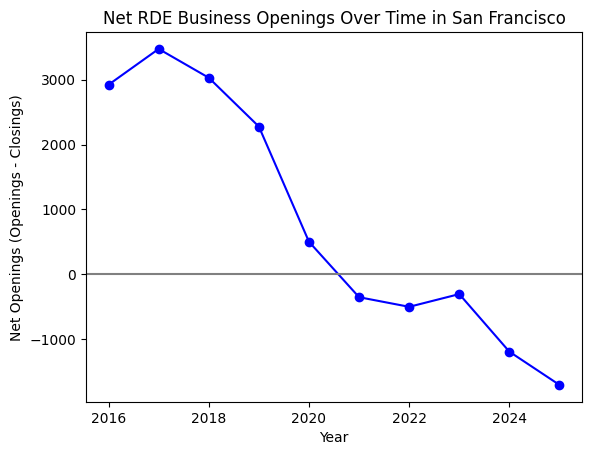

In [8]:
# Counting openings and closings by year
openings = df_filtered_start.groupby('open_year').size()
closings = df_filtered_end.groupby('close_year').size()

# Combining into one dataframe
net = pd.DataFrame({
    'openings': openings,
    'closings': closings
}).fillna(0)

# Calculating net change
net['net_openings'] = net['openings'] - net['closings']

# Sorting by year
net = net.sort_index()

plt.figure()
plt.plot(net.index, net['net_openings'], marker='o', color='blue')
plt.xlabel('Year')
plt.ylabel('Net Openings (Openings - Closings)')
plt.title('Net RDE Business Openings Over Time in San Francisco')
plt.axhline(0, color='gray')
plt.show()

/tmp/ipykernel_4715/1593795923.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_end['business_end_date'] = pd.to_datetime(df_filtered_end['business_end_date'], errors='coerce')


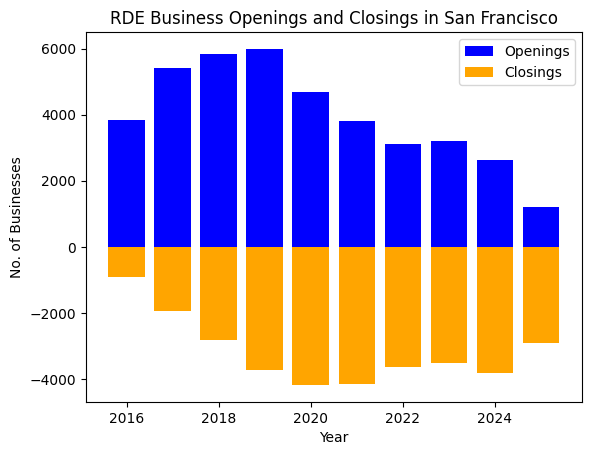

In [9]:

df_filtered_end['business_end_date'] = pd.to_datetime(df_filtered_end['business_end_date'], errors='coerce')

# Combining openings and closings
bars = pd.DataFrame({
    'openings': openings,
    'closings': closings
}).fillna(0)

# Making closings negative
bars['closings'] = -bars['closings']

# Sorting by year
bars = bars.sort_index()

plt.figure()
plt.bar(bars.index, bars['openings'], label='Openings', color='blue')
plt.bar(bars.index, bars['closings'], label='Closings', color='orange')
plt.xlabel('Year')
plt.ylabel('No. of Businesses')
plt.title('RDE Business Openings and Closings in San Francisco')
plt.legend()
plt.show()

In [10]:
#sanity checking values

openings = df_filtered_start.groupby('open_year').size()
openings

,0
open_year,
2016,3848
2017,5421
2018,5839
2019,5989
2020,4679
2021,3806
2022,3125
2023,3204
2024,2629


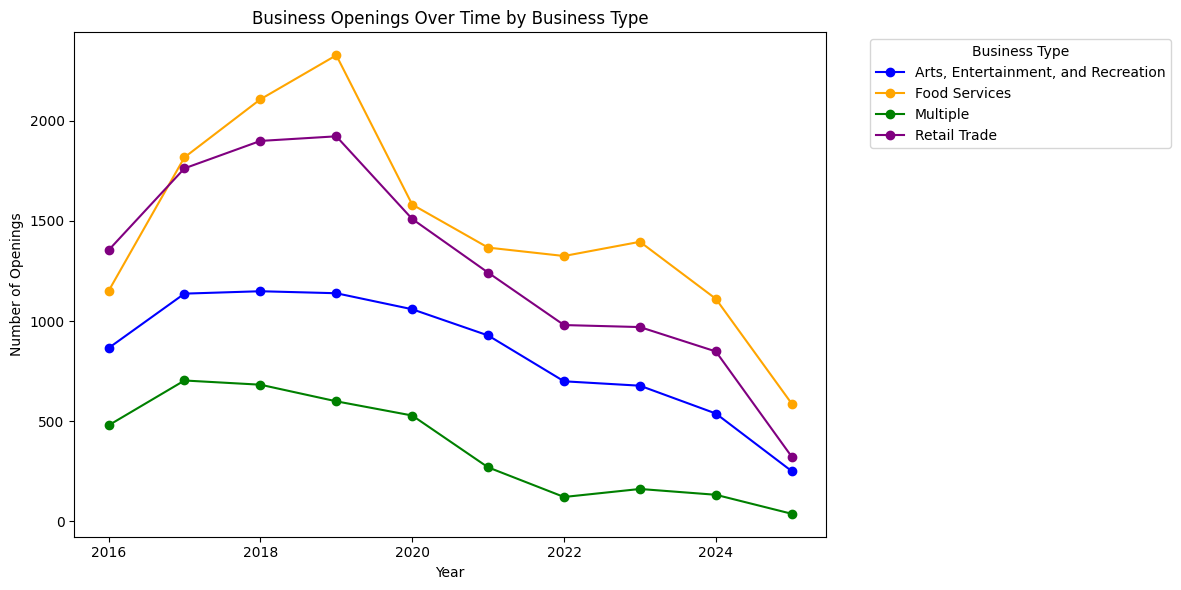

In [11]:
#Set up naics code descriptions to print and remove errant 2026 values
openings_by_type = df_filtered_start.groupby(['open_year', 'naics_code_description']).size().unstack(fill_value=0)
openings_by_type = openings_by_type[openings_by_type.index < 2026]

colors = ['blue', 'orange', 'green', 'purple']

plt.figure(figsize=(12, 6))

for i, business_type in enumerate(openings_by_type.columns):
    plt.plot(
        openings_by_type.index,
        openings_by_type[business_type],
        marker='o',
        label=business_type,
        color=colors[i % len(colors)]
    )
plt.title('Business Openings Over Time by Business Type')
plt.xlabel('Year')
plt.ylabel('Number of Openings')
plt.legend(title='Business Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

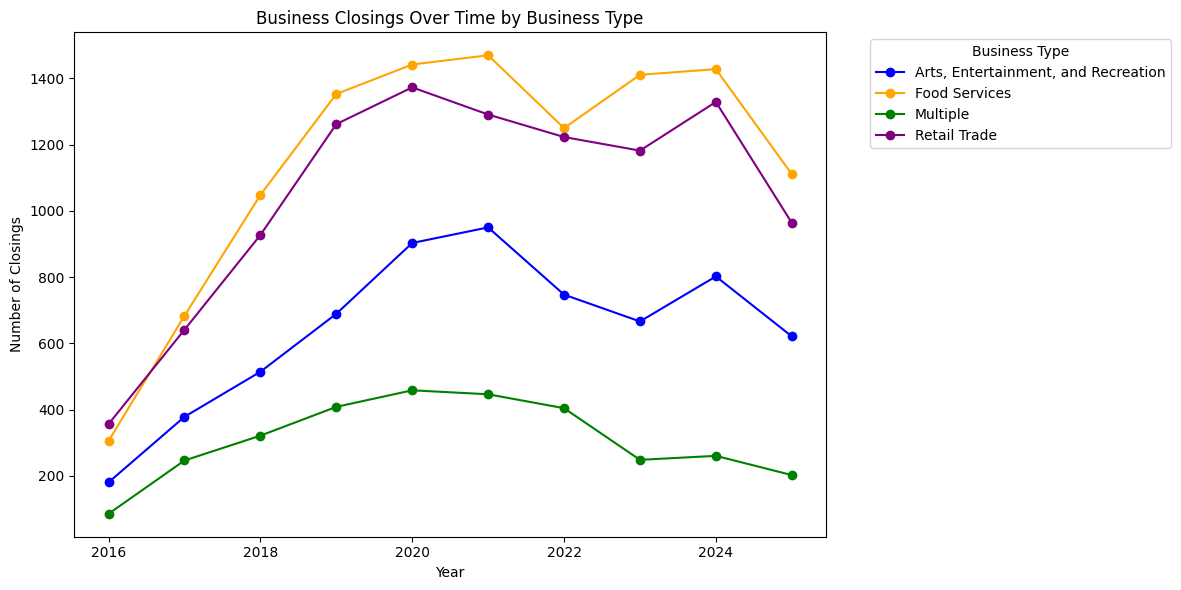

In [12]:
#Same thing for business closings
#Set up naics code descriptions to print and remove errant 2026 values
closings_by_type = df_filtered_end.groupby(['close_year', 'naics_code_description']).size().unstack(fill_value=0)
closings_by_type = closings_by_type[closings_by_type.index < 2026]

plt.figure(figsize=(12, 6))

for i, business_type in enumerate(closings_by_type.columns):
    plt.plot(
        closings_by_type.index,
        closings_by_type[business_type],
        marker='o',
        label=business_type,
        color=colors[i % len(colors)]
    )

plt.title('Business Closings Over Time by Business Type')
plt.xlabel('Year')
plt.ylabel('Number of Closings')
plt.legend(title='Business Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [13]:
# Combine openings and closings again
pct_df = pd.DataFrame({
    'openings': openings,
    'closings': closings
}).fillna(0)

pct_df = pct_df.sort_index()

# Keep only 2016–2025
pct_df = pct_df[(pct_df.index >= 2016) & (pct_df.index < 2026)]

In [14]:
baseline_open = pct_df.loc[2016, 'openings']
baseline_close = pct_df.loc[2016, 'closings']

pct_df['openings_pct_change'] = ((pct_df['openings'] - baseline_open) / baseline_open) * 100
pct_df['closings_pct_change'] = ((pct_df['closings'] - baseline_close) / baseline_close) * 100

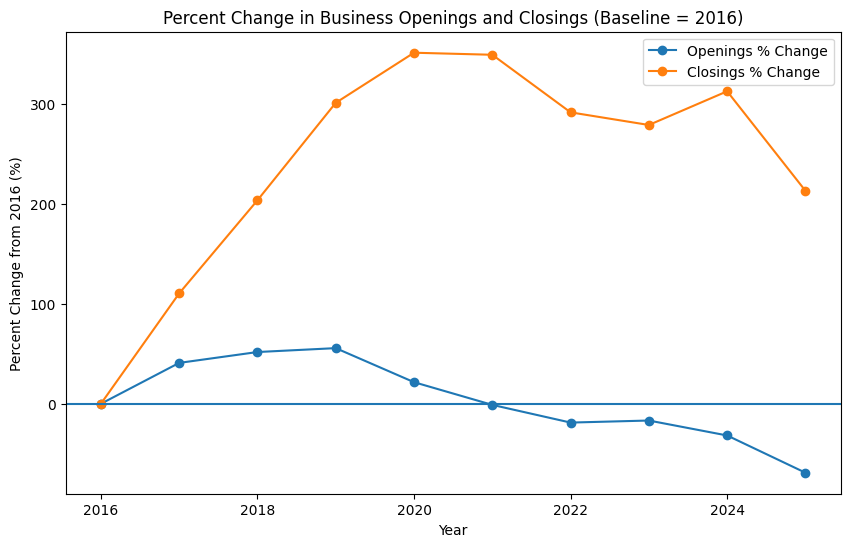

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(pct_df.index, pct_df['openings_pct_change'], marker='o', label='Openings % Change')
plt.plot(pct_df.index, pct_df['closings_pct_change'], marker='o', label='Closings % Change')

plt.axhline(0)  # baseline reference
plt.xlabel('Year')
plt.ylabel('Percent Change from 2016 (%)')
plt.title('Percent Change in Business Openings and Closings (Baseline = 2016)')
plt.legend()
plt.show()

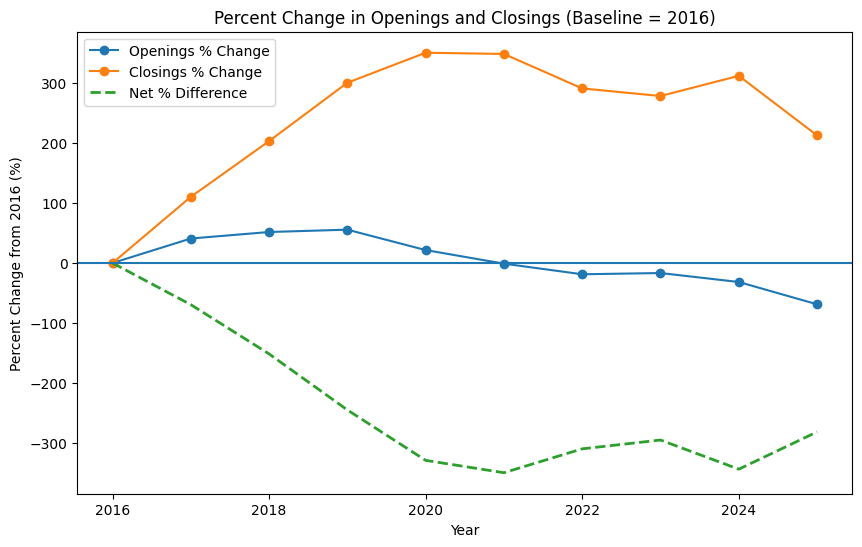

In [16]:
plt.figure(figsize=(10, 6))

# Plot percent changes
plt.plot(pct_df.index, pct_df['openings_pct_change'], marker='o', label='Openings % Change')
plt.plot(pct_df.index, pct_df['closings_pct_change'], marker='o', label='Closings % Change')

# Net difference in percent change
pct_df['net_pct_diff'] = pct_df['openings_pct_change'] - pct_df['closings_pct_change']

plt.plot(pct_df.index, pct_df['net_pct_diff'], linestyle='--', linewidth=2, label='Net % Difference')

plt.axhline(0)
plt.xlabel('Year')
plt.ylabel('Percent Change from 2016 (%)')
plt.title('Percent Change in Openings and Closings (Baseline = 2016)')
plt.legend()

plt.show()

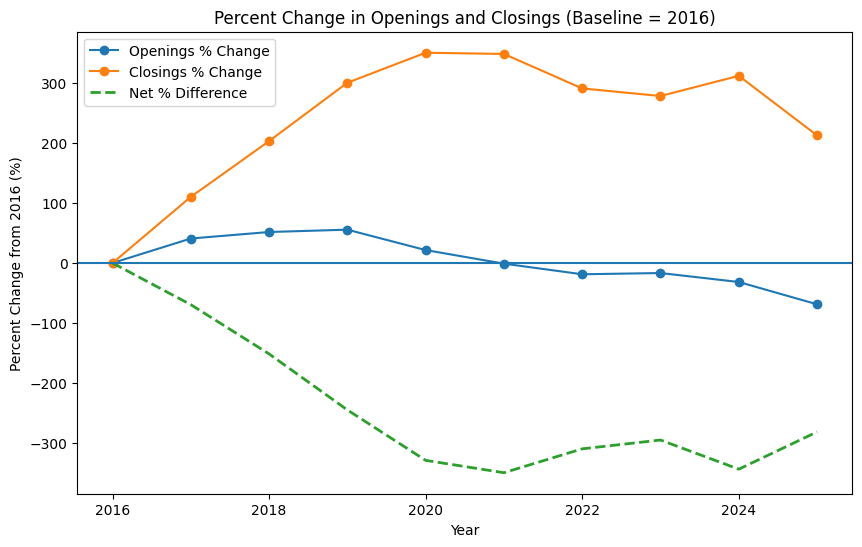

In [17]:
plt.figure(figsize=(10, 6))

# Plot percent changes
plt.plot(pct_df.index, pct_df['openings_pct_change'], marker='o', label='Openings % Change')
plt.plot(pct_df.index, pct_df['closings_pct_change'], marker='o', label='Closings % Change')

# Net difference in percent change
pct_df['net_pct_diff'] = pct_df['openings_pct_change'] - pct_df['closings_pct_change']

plt.plot(pct_df.index, pct_df['net_pct_diff'], linestyle='--', linewidth=2, label='Net % Difference')

plt.axhline(0)
plt.xlabel('Year')
plt.ylabel('Percent Change from 2016 (%)')
plt.title('Percent Change in Openings and Closings (Baseline = 2016)')
plt.legend()

plt.show()

In [18]:
df_sf = pd.read_csv('/content/drive/MyDrive/C255_final_project/cleaned/rbl_total_cleaned.csv')

In [19]:
df_sf['location_start_date'] = pd.to_datetime(df_sf['location_start_date'], errors='coerce')
df_sf['location_end_date'] = pd.to_datetime(df_sf['location_end_date'], errors='coerce')

#creating two dataframes to represent businesses opening/closing within our timeframe (businesses opening 2016 onwards and businesses closing pre-2026)

df_filtered_start_sf = df_sf[
    (df_sf['location_start_date'] >= '2016-01-01') &
    (df_sf['location_start_date'] < '2026-01-01')
]
df_filtered_end_sf = df_sf[
    (df_sf['location_end_date'] < '2026-01-01') &
    (df_sf['location_end_date'] >= '2016-01-01')
]

In [20]:
#converting values to datetime and creating a new column for the necessary year
df_filtered_start_sf['location_start_date'] = pd.to_datetime(df_filtered_start_sf['location_start_date'], errors='coerce')
df_filtered_end_sf['location_end_date'] = pd.to_datetime(df_filtered_end_sf['location_end_date'], errors='coerce')

df_filtered_start_sf['open_year'] = df_filtered_start_sf['location_start_date'].dt.year
df_filtered_end_sf['close_year'] = df_filtered_end_sf['location_end_date'].dt.year

/tmp/ipykernel_4715/3371251549.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_start_sf['location_start_date'] = pd.to_datetime(df_filtered_start_sf['location_start_date'], errors='coerce')
/tmp/ipykernel_4715/3371251549.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_end_sf['location_end_date'] = pd.to_datetime(df_filtered_end_sf['location_end_date'], errors='coerce')
/tmp/ipykernel_4715/3371251549.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

In [21]:
openings = df_filtered_start_sf.groupby('open_year').size()
closings = df_filtered_end_sf.groupby('close_year').size()

# Combine openings and closings again
pct_df_sf = pd.DataFrame({
    'openings_sf': openings,
    'closings_sf': closings
}).fillna(0)

pct_df_sf = pct_df_sf.sort_index()

# Keep only 2016–2025
pct_df_sf = pct_df_sf[(pct_df_sf.index >= 2016) & (pct_df_sf.index < 2026)]

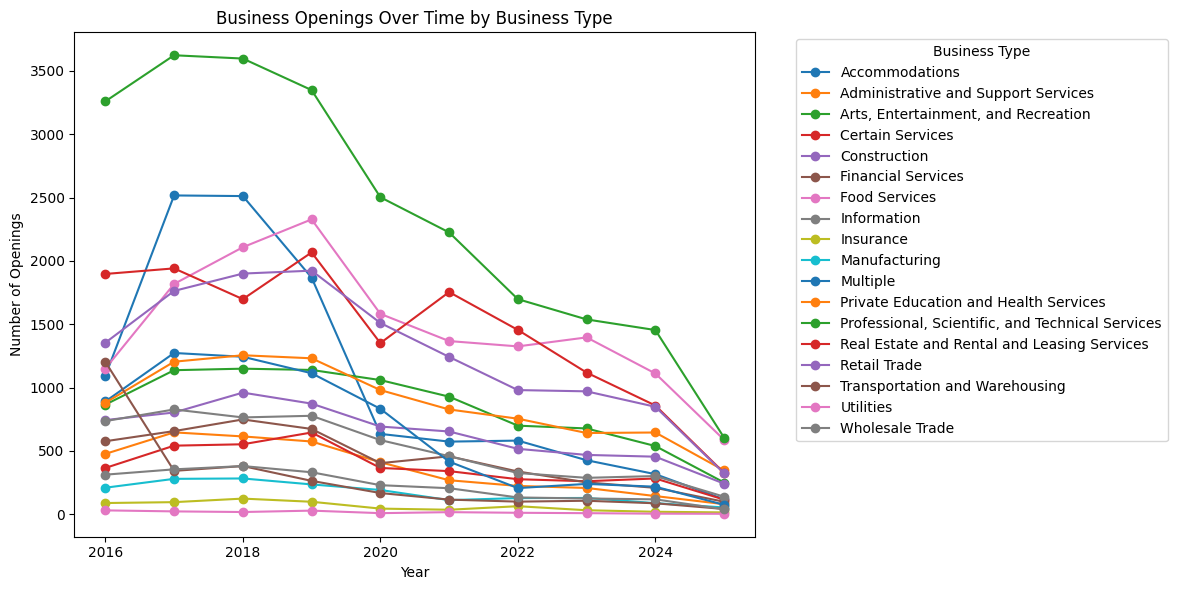

In [22]:
#Set up naics code descriptions to print and remove errant 2026 values
openings_by_type_sf = df_filtered_start_sf.groupby(['open_year', 'naics_code_description']).size().unstack(fill_value=0)
openings_by_type_sf = openings_by_type_sf[openings_by_type_sf.index < 2026]

plt.figure(figsize=(12, 6))

for i, business_type in enumerate(openings_by_type_sf.columns):
    plt.plot(
        openings_by_type_sf.index,
        openings_by_type_sf[business_type],
        marker='o',
        label=business_type,
    )
plt.title('Business Openings Over Time by Business Type')
plt.xlabel('Year')
plt.ylabel('Number of Openings')
plt.legend(title='Business Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [23]:
rde_naics = df['naics_code'].dropna().unique()
df_sf_non_rde = df_sf[~df_sf['naics_code'].isin(rde_naics)].copy()

df_filtered_start_non_rde = df_sf_non_rde[
    (df_sf_non_rde['location_start_date'] >= '2016-01-01') &
    (df_sf_non_rde['location_start_date'] < '2026-01-01')
].copy()

df_filtered_start_non_rde['open_year'] = pd.to_datetime(
    df_filtered_start_non_rde['location_start_date'],
    errors='coerce'
).dt.year

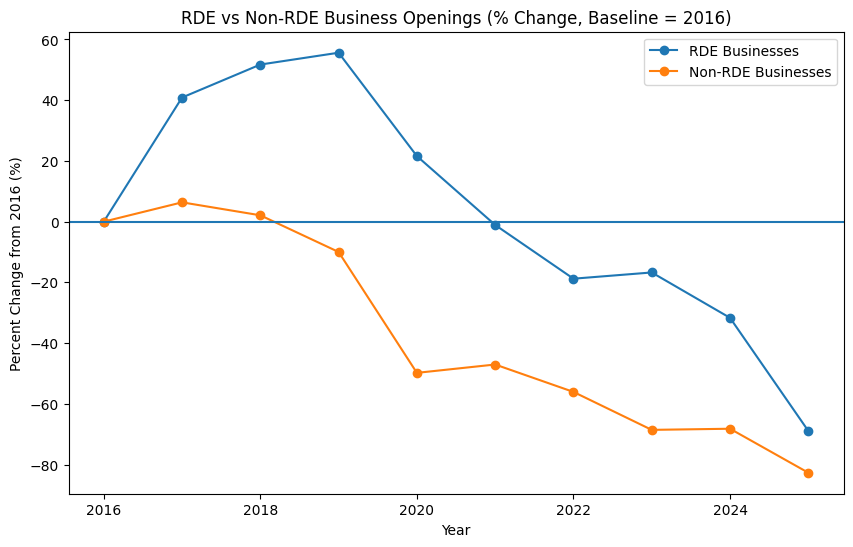

In [24]:
# RDE openings
rde_openings = df_filtered_start.groupby('open_year').size()

# All SF openings
sf_openings = df_filtered_start_non_rde.groupby('open_year').size()

# Combine into one dataframe
compare_df = pd.DataFrame({
    'rde_openings': rde_openings,
    'sf_openings': sf_openings
}).fillna(0)

# Sort and limit years
compare_df = compare_df.sort_index()
compare_df = compare_df[(compare_df.index >= 2016) & (compare_df.index < 2026)]

# Create NON-RDE
compare_df['non_rde_openings'] = compare_df['sf_openings'] - compare_df['rde_openings']

# Percent change from 2016 baseline
baseline_rde = compare_df.loc[2016, 'rde_openings']
baseline_non_rde = compare_df.loc[2016, 'non_rde_openings']

compare_df['rde_pct_change'] = ((compare_df['rde_openings'] - baseline_rde) / baseline_rde) * 100
compare_df['non_rde_pct_change'] = ((compare_df['non_rde_openings'] - baseline_non_rde) / baseline_non_rde) * 100

plt.figure(figsize=(10, 6))

plt.plot(compare_df.index, compare_df['rde_pct_change'], marker='o', label='RDE Businesses')
plt.plot(compare_df.index, compare_df['non_rde_pct_change'], marker='o', label='Non-RDE Businesses')

plt.axhline(0)
plt.xlabel('Year')
plt.ylabel('Percent Change from 2016 (%)')
plt.title('RDE vs Non-RDE Business Openings (% Change, Baseline = 2016)')
plt.legend()

plt.show()

In [25]:
# Setting up same thing for net closings

df_filtered_end_non_rde = df_sf_non_rde[
    (df_sf_non_rde['location_end_date'] >= '2016-01-01') &
    (df_sf_non_rde['location_end_date'] < '2026-01-01')
].copy()

df_filtered_end_non_rde['close_year'] = pd.to_datetime(
    df_filtered_end_non_rde['location_end_date'],
    errors='coerce'
).dt.year

In [26]:
# RDE
rde_openings = df_filtered_start.groupby('open_year').size()
rde_closings = df_filtered_end.groupby('close_year').size()

# Non-RDE
non_rde_openings = df_filtered_start_non_rde.groupby('open_year').size()
non_rde_closings = df_filtered_end_non_rde.groupby('close_year').size()

In [27]:
compare_net = pd.DataFrame({
    'rde_openings': rde_openings,
    'rde_closings': rde_closings,
    'non_rde_openings': non_rde_openings,
    'non_rde_closings': non_rde_closings
}).fillna(0)

compare_net = compare_net.sort_index()
compare_net = compare_net[(compare_net.index >= 2016) & (compare_net.index < 2026)]

In [28]:
compare_net['rde_net'] = compare_net['rde_openings'] - compare_net['rde_closings']
compare_net['non_rde_net'] = compare_net['non_rde_openings'] - compare_net['non_rde_closings']

In [29]:
baseline_rde = compare_net.loc[2016, 'rde_net']
baseline_non_rde = compare_net.loc[2016, 'non_rde_net']

compare_net['rde_net_pct_change'] = ((compare_net['rde_net'] - baseline_rde) / abs(baseline_rde)) * 100
compare_net['non_rde_net_pct_change'] = ((compare_net['non_rde_net'] - baseline_non_rde) / abs(baseline_non_rde)) * 100

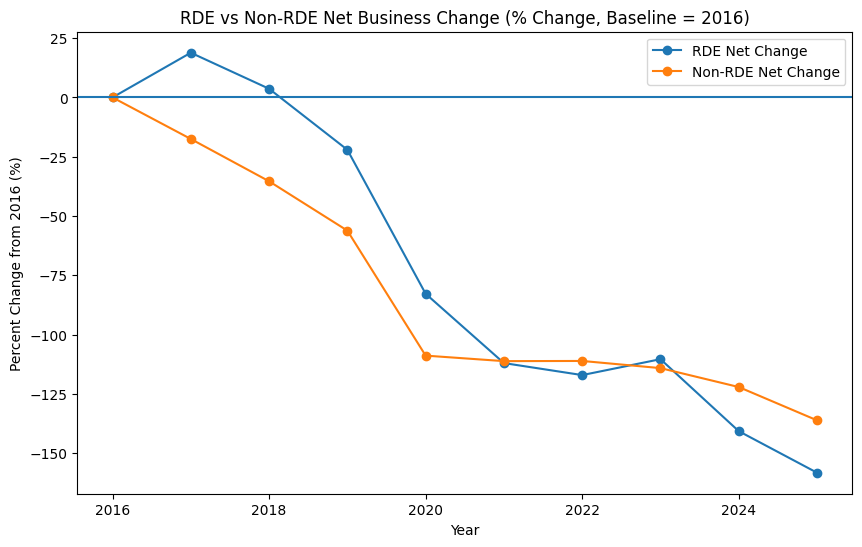

In [30]:
plt.figure(figsize=(10, 6))

plt.plot(compare_net.index, compare_net['rde_net_pct_change'], marker='o', label='RDE Net Change')
plt.plot(compare_net.index, compare_net['non_rde_net_pct_change'], marker='o', label='Non-RDE Net Change')

plt.axhline(0)
plt.xlabel('Year')
plt.ylabel('Percent Change from 2016 (%)')
plt.title('RDE vs Non-RDE Net Business Change (% Change, Baseline = 2016)')
plt.legend()

plt.show()

In [42]:
tracts_gdf = gpd.read_file(
    "/content/drive/MyDrive/C255_final_project/cb_2020_06_tract_500k"
)

#checking to make sure all good

tracts_gdf.columns

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'AFFGEOID', 'GEOID', 'NAME',
       'NAMELSAD', 'STUSPS', 'NAMELSADCO', 'STATE_NAME', 'LSAD', 'ALAND',
       'AWATER', 'geometry'],
      dtype='object')

In [43]:
# simplifying
tracts_gdf = tracts_gdf[["NAME", "NAMELSAD", "STATE_NAME","GEOID", "geometry"]]

In [44]:
# was getting error with "index_right" - so troubleshooted this
tracts_gdf = tracts_gdf.drop(columns=["index_right", ], errors="ignore")
df_sf_non_rde = df_sf_non_rde.drop(columns=["index_right"], errors="ignore")

In [48]:
df_sf.columns

Index(['Unnamed: 0', 'uniqueid', 'business_account_number', 'location_id',
       'ownership_name', 'dba_name', 'street_address', 'city', 'state',
       'source_zipcode', 'business_start_date', 'business_end_date',
       'location_start_date', 'location_end_date', 'administratively_closed',
       'mail_address', 'mail_city', 'mail_state', 'mail_zipcode', 'naics_code',
       'naics_code_description', 'naics_code_descriptions_list', 'lic_code',
       'lic_code_description', 'lic_code_descriptions_list', 'parking_tax',
       'transient_occupancy_tax', 'business_location', 'business_corridor',
       'neighborhoods_analysis_boundaries', 'supervisor_district',
       'community_benefit_district', 'data_as_of', 'data_loaded_at',
       'geometry', 'administratively_closed_bool', 'year', 'status', 'lon',
       'lat'],
      dtype='object')

In [64]:
from shapely.geometry import Point

# create geometry column
df_sf['geometry'] = gpd.points_from_xy(df_sf['lon'], df_sf['lat'])

# convert to GeoDataFrame
gdf_sf = gpd.GeoDataFrame(df_sf, geometry='geometry', crs='EPSG:4269')

In [65]:
tracts_gdf = tracts_gdf.to_crs(gdf_sf.crs)

In [66]:
# keep only San Francisco County tracts
tracts_gdf = tracts_gdf[tracts_gdf['GEOID'].str[2:5] == '075']

In [67]:
gdf_joined = gpd.sjoin(gdf_sf, tracts_gdf, how='left', predicate='within')

In [68]:
# openings
gdf_open = gdf_joined[
    (gdf_joined['location_start_date'] >= '2016-01-01') &
    (gdf_joined['location_start_date'] < '2026-01-01')
].copy()

# closings
gdf_close = gdf_joined[
    (gdf_joined['location_end_date'] >= '2016-01-01') &
    (gdf_joined['location_end_date'] < '2026-01-01')
].copy()

In [69]:
# count by tract
openings_by_tract = gdf_open.groupby('GEOID').size()
closings_by_tract = gdf_close.groupby('GEOID').size()

tract_counts = pd.DataFrame({
    'openings': openings_by_tract,
    'closings': closings_by_tract
}).fillna(0)

# net change
tract_counts['net'] = tract_counts['openings'] - tract_counts['closings']

In [70]:
tracts_map = tracts_gdf.merge(
    tract_counts,
    on='GEOID',
    how='left'
)

# fill missing tracts with 0
tracts_map[['openings', 'closings', 'net']] = tracts_map[
    ['openings', 'closings', 'net']
].fillna(0)

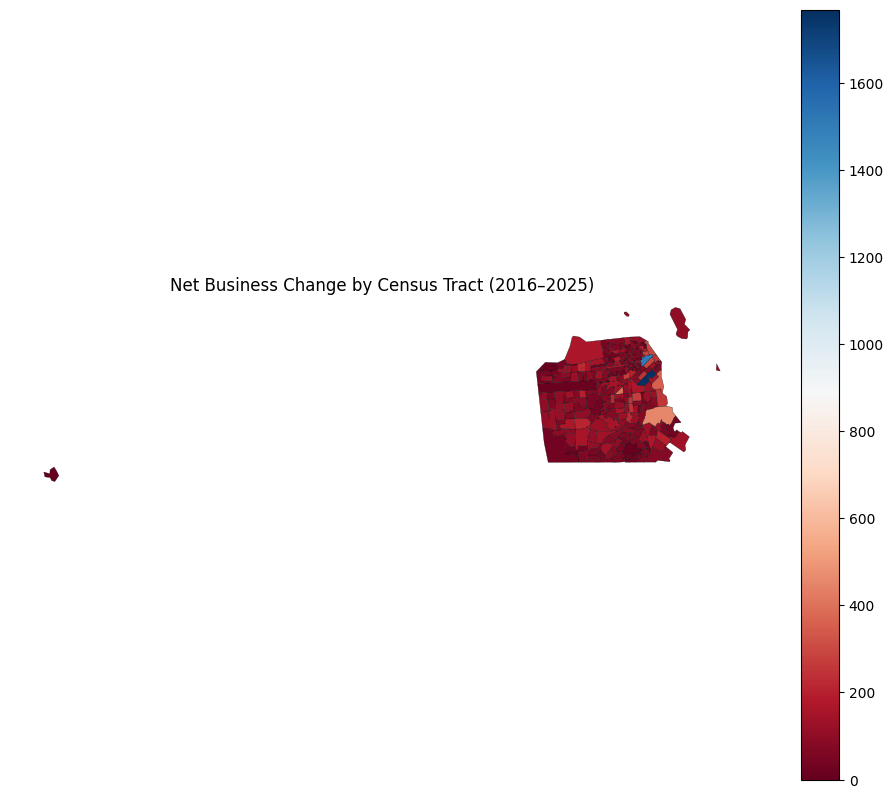

In [71]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

tracts_map.plot(
    column='net',
    cmap='RdBu',   # red = losses, blue = gains
    legend=True,
    ax=ax,
    edgecolor='black',
    linewidth=0.2
)

ax.set_title('Net Business Change by Census Tract (2016–2025)')
ax.axis('off')

plt.show()